# 🦎 Lizard Species Classification – Deep Learning Challenge
**Thomas More – Deep Learning Project**

---

## 📋 Projectoverzicht

In dit notebook bouwen we een **Convolutional Neural Network (CNN)** om 7 soorten hagedissen te classificeren aan de hand van foto's.

| Klasse | Label |
|--------|-------|
| Black spiny-tailed iguana | 0 |
| Brown anole | 1 |
| Cuban knight anole | 2 |
| Desert iguana | 3 |
| Green anole | 4 |
| Green iguana | 5 |
| Lesser Antillean iguana | 6 |

### Stappen:
1. Imports & Configuratie
2. EDA (Exploratory Data Analysis)
3. Data preprocessing & augmentatie
4. **Eigen CNN bouwen**
5. **Transfer Learning (EfficientNetV2M high-accuracy)**
6. Training visualiseren
7. Evaluatie (confusion matrix)
8. Kaggle submission met TTA en optioneel ensemble

---
## 1. 📦 Imports & Configuratie

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

print(f"TensorFlow versie: {tf.__version__}")
print(f"GPU beschikbaar:   {len(tf.config.list_physical_devices('GPU')) > 0}")

I0000 00:00:1778059110.433728   13024 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778059110.503570   13024 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778059112.127310   13024 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow versie: 2.21.0
GPU beschikbaar:   True


In [2]:
# ?? Paden ? pas aan aan jouw mappenstructuur ??????????????????????????????
BASE_DIR   = Path("lizard-prediction-thomas-more")
TRAIN_DIR  = BASE_DIR / "train"   # submappen per klasse
TEST_DIR   = BASE_DIR / "test"    # losse afbeeldingen: 1.jpg, 2.jpg, ...
TRAIN_CSV  = BASE_DIR / "train.csv"
TEST_CSV   = BASE_DIR / "test.csv"
SAMPLE_SUB = BASE_DIR / "sample_submission.csv"

# ?? Hyperparameters ???????????????????????????????????????????????????????
# PowerPoint-logica: transfer learning + sterkere backbone + voorzichtig fine-tunen.
# RTX 4050 heeft meestal 6GB VRAM: EfficientNetV2M is krachtig maar nog haalbaar.
IMG_SIZE   = (240, 240)   # hogere resolutie dan 224 voor meer detail in de hagedissen
BATCH_SIZE = 16           # lager door grotere backbone/resolutie; bij OOM: 8 gebruiken
SEED       = 42
NUM_TTA    = 10           # tip uit screenshot: van 7 naar 10

BACKBONE_NAME = "EfficientNetV2M"  # Optie voor heel sterke GPU: "EfficientNetV2L"
USE_MIXUP_CUTMIX = True
MIXUP_ALPHA = 0.20
CUTMIX_ALPHA = 0.50

# ?? Klassen (volgorde = label 0-6 in train.csv) ??????????????????????????
CLASS_NAMES = [
    "Black_spiny-tailed_iguana",  # 0
    "Brown_anole",                # 1
    "Cuban_knight_anole",         # 2
    "Desert_iguana",              # 3
    "Green_anole",                # 4
    "Green_iguana",               # 5
    "Lesser_Antillean_iguana",    # 6
]
NUM_CLASSES = len(CLASS_NAMES)

tf.random.set_seed(SEED)
np.random.seed(SEED)
print(f"Aantal klassen: {NUM_CLASSES}")
print(f"Backbone: {BACKBONE_NAME}, image size: {IMG_SIZE}, batch size: {BATCH_SIZE}")

Aantal klassen: 7
Backbone: EfficientNetV2M, image size: (240, 240), batch size: 16


---
## 2. 🔍 EDA – Exploratory Data Analysis

Voordat we een model bouwen, verkennen we de data:
- Hoeveel afbeeldingen per klasse?
- Zijn de klassen gebalanceerd?
- Hoe zien de afbeeldingen eruit?
- Wat zijn de afmetingen?

In [3]:
# CSV laden en bekijken
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("=== train.csv ===")
print(f"Shape: {train_df.shape}")
print(train_df.head(10))
print(f"\nDatatypes:\n{train_df.dtypes}")
print(f"\nOntbrekende waarden:\n{train_df.isnull().sum()}")

=== train.csv ===
Shape: (1334, 2)
                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
5  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
6  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
7  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
8  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
9  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0

Datatypes:
id         str
label    int64
dtype: object

Ontbrekende waarden:
id       0
label    0
dtype: int64


In [4]:
print("=== test.csv ===")
print(f"Shape: {test_df.shape}")
print(test_df.head())
print(f"\nID range: {test_df['id'].min()} – {test_df['id'].max()}")

=== test.csv ===
Shape: (326, 1)
   id
0   1
1   2
2   3
3   4
4   5

ID range: 1 – 326


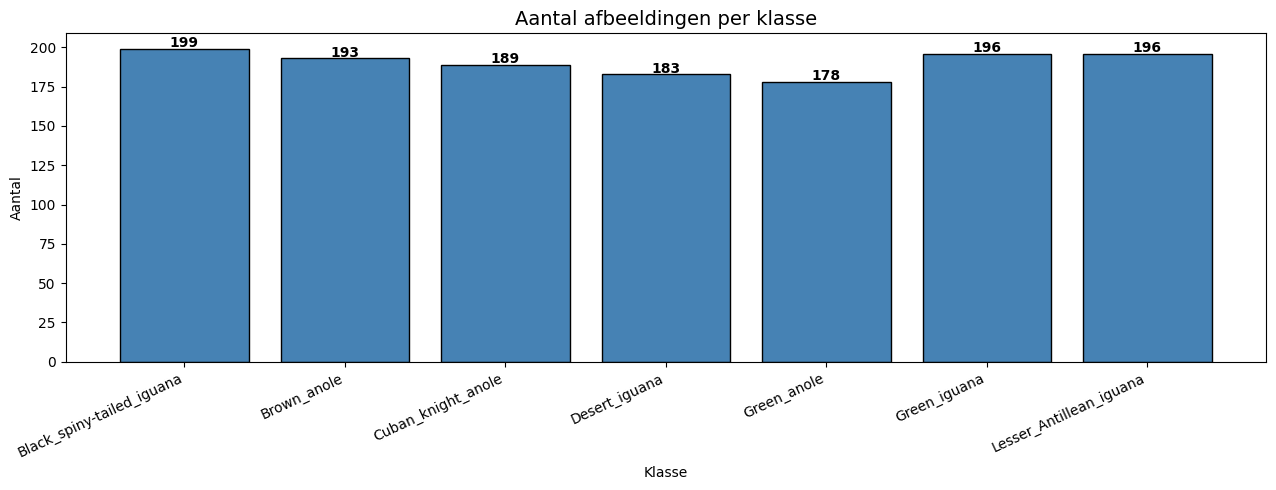


Totaal trainingsafbeeldingen: 1334
Minimum per klasse: 178 | Maximum: 199
→ Dataset is relatief gebalanceerd, geen class weighting nodig.


In [5]:
# Klasse-verdeling
label_counts = train_df['label'].value_counts().sort_index()
class_labels = [CLASS_NAMES[i] for i in label_counts.index]

plt.figure(figsize=(13, 5))
bars = plt.bar(class_labels, label_counts.values, color='steelblue', edgecolor='black')
for bar, cnt in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(cnt), ha='center', fontweight='bold')
plt.title("Aantal afbeeldingen per klasse", fontsize=14)
plt.xlabel("Klasse")
plt.ylabel("Aantal")
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotaal trainingsafbeeldingen: {len(train_df)}")
print(f"Minimum per klasse: {label_counts.min()} | Maximum: {label_counts.max()}")
print("→ Dataset is relatief gebalanceerd, geen class weighting nodig.")

In [6]:
# Bestandspaden opzoeken voor train_df
def find_image_path(row):
    filename = row['id']
    cls_name = CLASS_NAMES[row['label']]
    candidate = TRAIN_DIR / cls_name / filename
    if candidate.exists():
        return str(candidate)
    for subdir in TRAIN_DIR.iterdir():
        p = subdir / filename
        if p.exists():
            return str(p)
    return None

train_df['filepath'] = train_df.apply(find_image_path, axis=1)
print(f"Gevonden: {train_df['filepath'].notna().sum()}/{len(train_df)} afbeeldingen")
train_df = train_df.dropna(subset=['filepath'])

Gevonden: 1334/1334 afbeeldingen


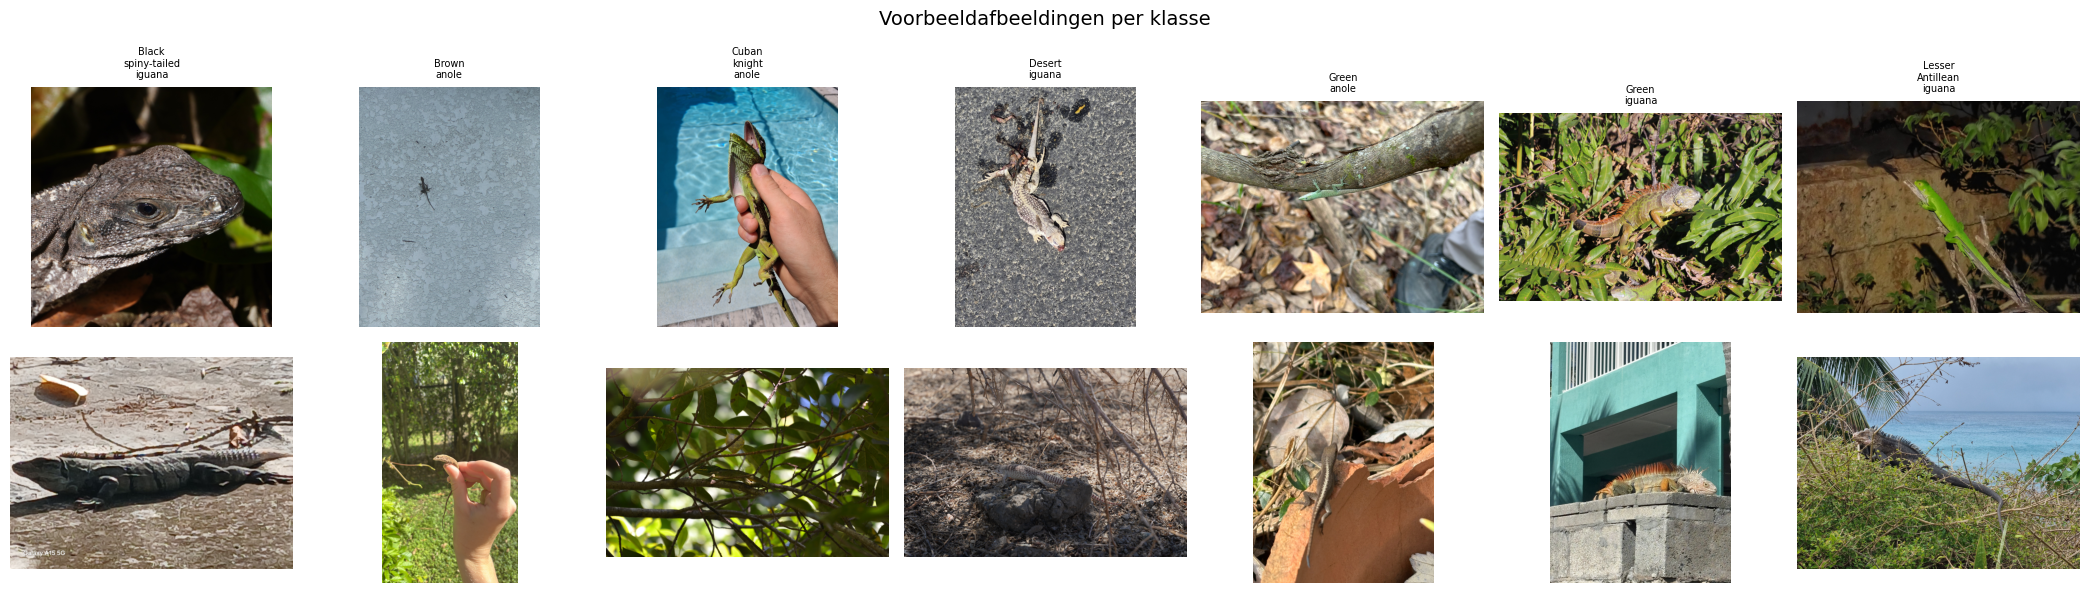

In [7]:
# Voorbeeldafbeeldingen per klasse
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES * 3, 6))
for col, cls in enumerate(CLASS_NAMES):
    subset = train_df[train_df['label'] == col]
    sample = subset.sample(min(2, len(subset)), random_state=SEED)
    for row, (_, r) in enumerate(sample.iterrows()):
        ax = axes[row][col]
        ax.imshow(mpimg.imread(r['filepath']))
        ax.axis('off')
        if row == 0:
            ax.set_title(cls.replace('_', '\n'), fontsize=7)
plt.suptitle("Voorbeeldafbeeldingen per klasse", fontsize=14)
plt.tight_layout()
plt.show()

Breedte  – min: 615, max: 2048, gem: 1677px
Hoogte   – min: 461, max: 2048, gem: 1730px
→ Afbeeldingen worden herschaald naar 240×240px voor het model.


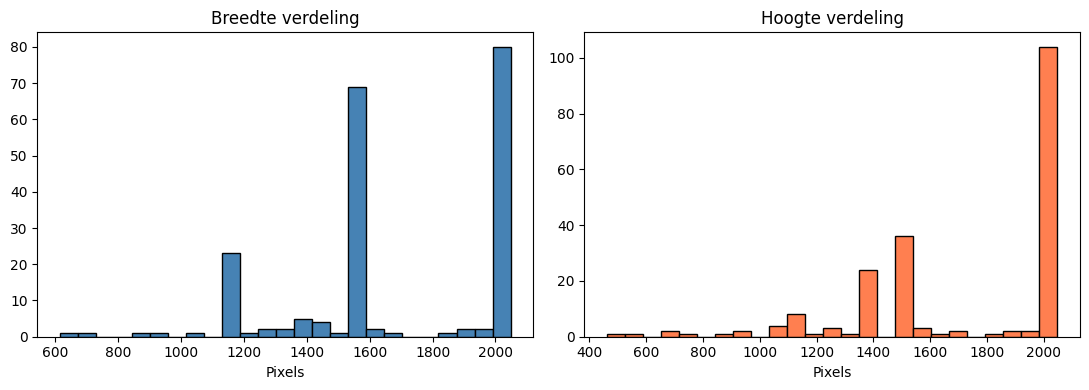

In [8]:
# Afbeeldingsafmetingen analyseren
widths, heights = [], []
for _, row in train_df.sample(min(200, len(train_df)), random_state=SEED).iterrows():
    try:
        with Image.open(row['filepath']) as im:
            widths.append(im.width)
            heights.append(im.height)
    except:
        pass

print(f"Breedte  – min: {min(widths)}, max: {max(widths)}, gem: {np.mean(widths):.0f}px")
print(f"Hoogte   – min: {min(heights)}, max: {max(heights)}, gem: {np.mean(heights):.0f}px")
print(f"→ Afbeeldingen worden herschaald naar {IMG_SIZE[0]}×{IMG_SIZE[1]}px voor het model.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(widths,  bins=25, color='steelblue', edgecolor='black')
axes[0].set_title("Breedte verdeling"); axes[0].set_xlabel("Pixels")
axes[1].hist(heights, bins=25, color='coral',     edgecolor='black')
axes[1].set_title("Hoogte verdeling");  axes[1].set_xlabel("Pixels")
plt.tight_layout()
plt.show()

---
## 3. 🔄 Data Preprocessing & Augmentatie

### Wat is Data Augmentatie?
Data augmentatie past willekeurige transformaties toe op trainingsafbeeldingen:
- **Flip** – spiegel horizontaal/verticaal
- **Rotatie** – draai willekeurig
- **Zoom** – willekeurig inzoomen (via random crop + resize)
- **Helderheid / Contrast** – kleurwijzigingen

**Doel:** het model ziet elke epoch een licht andere versie van de foto → beter generaliseren, minder overfitting.

> ⚠️ Augmentatie wordt **alleen tijdens training** toegepast, nooit op validatie of testdata!

In [9]:
# Train / validatie split (stratified: zelfde verhouding per klasse)
train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],
    random_state=SEED
)
print(f"Training:   {len(train_split)} afbeeldingen")
print(f"Validatie:  {len(val_split)} afbeeldingen")

Training:   1067 afbeeldingen
Validatie:  267 afbeeldingen


In [10]:
# ?? Augmentatie functie ???????????????????????????????????????????????????
@tf.function
def augment_image(img):
    """Willekeurige transformaties ? enkel voor training.

    Gebaseerd op de powerpoints: augmentatie vergroot de dataset virtueel en helpt
    tegen overfitting. We houden de transformaties realistisch voor hagedisfoto's.
    """
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.25)
    img = tf.image.random_contrast(img, 0.75, 1.25)
    img = tf.image.random_saturation(img, 0.80, 1.20)
    img = tf.image.random_hue(img, 0.05)

    # Zoom simuleren via random crop + resize.
    scale = tf.random.uniform([], 0.78, 1.0)
    h = tf.cast(IMG_SIZE[0] * scale, tf.int32)
    w = tf.cast(IMG_SIZE[1] * scale, tf.int32)
    img = tf.image.random_crop(img, size=[h, w, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img

# EfficientNetV2 met include_preprocessing=True verwacht raw RGB [0,255].
# Voor de eigen CNN schalen we naar [0,1]; voor transfer learning gebruiken we raw beelden.
def load_image_raw(filepath, label, augment=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = augment_image(img)
    label_onehot = tf.one_hot(label, NUM_CLASSES)
    return img, label_onehot

def load_image_cnn(filepath, label, augment=False):
    img, label_onehot = load_image_raw(filepath, label, augment)
    return img / 255.0, label_onehot

def make_dataset(df, augment=False, shuffle=False, for_transfer=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['filepath'].tolist(), df['label'].tolist())
    )
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    loader = load_image_raw if for_transfer else load_image_cnn
    ds = ds.map(lambda p, l: loader(p, l, augment), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Beta sampling zonder tensorflow_probability: Gamma(a,1)/(Gamma(a,1)+Gamma(a,1)).
def sample_beta(alpha):
    gamma1 = tf.random.gamma([], alpha, 1.0)
    gamma2 = tf.random.gamma([], alpha, 1.0)
    return gamma1 / (gamma1 + gamma2)

def mixup_batch(images, labels, alpha=MIXUP_ALPHA):
    batch_size = tf.shape(images)[0]
    lam = sample_beta(alpha)
    indices = tf.random.shuffle(tf.range(batch_size))
    mixed_images = lam * images + (1.0 - lam) * tf.gather(images, indices)
    mixed_labels = lam * labels + (1.0 - lam) * tf.gather(labels, indices)
    return mixed_images, mixed_labels

def cutmix_batch(images, labels, alpha=CUTMIX_ALPHA):
    batch_size = tf.shape(images)[0]
    img_h = tf.shape(images)[1]
    img_w = tf.shape(images)[2]
    lam = sample_beta(alpha)
    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(images, indices)
    shuffled_labels = tf.gather(labels, indices)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_ratio, tf.int32)
    cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_ratio, tf.int32)
    cy = tf.random.uniform([], 0, img_h, dtype=tf.int32)
    cx = tf.random.uniform([], 0, img_w, dtype=tf.int32)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, img_h)
    y2 = tf.clip_by_value(cy + cut_h // 2, 0, img_h)
    x1 = tf.clip_by_value(cx - cut_w // 2, 0, img_w)
    x2 = tf.clip_by_value(cx + cut_w // 2, 0, img_w)

    yy = tf.range(img_h)[:, None]
    xx = tf.range(img_w)[None, :]
    mask = tf.cast((yy >= y1) & (yy < y2) & (xx >= x1) & (xx < x2), images.dtype)
    mask = tf.reshape(mask, (1, img_h, img_w, 1))

    mixed_images = images * (1.0 - mask) + shuffled_images * mask
    area = tf.cast((y2 - y1) * (x2 - x1), tf.float32)
    lam_adjusted = 1.0 - area / tf.cast(img_h * img_w, tf.float32)
    mixed_labels = lam_adjusted * labels + (1.0 - lam_adjusted) * shuffled_labels
    return mixed_images, mixed_labels

def mixup_or_cutmix(images, labels):
    return tf.cond(
        tf.random.uniform([]) < 0.5,
        lambda: mixup_batch(images, labels),
        lambda: cutmix_batch(images, labels),
    )

# Eigen CNN blijft didactisch zoals in de powerpoints; transfer learning krijgt de sterke pipeline.
train_ds = make_dataset(train_split, augment=True,  shuffle=True,  for_transfer=False)
val_ds   = make_dataset(val_split,   augment=False, shuffle=False, for_transfer=True)

train_ds_tl = make_dataset(train_split, augment=True, shuffle=True, for_transfer=True)
if USE_MIXUP_CUTMIX:
    train_ds_tl = train_ds_tl.map(mixup_or_cutmix, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

print("? Datasets aangemaakt")
print("Eigen CNN dataset: [0,1] geschaald")
print("Transfer learning dataset: raw RGB [0,255] + EfficientNetV2 preprocessing in het model")
print(f"MixUp/CutMix actief: {USE_MIXUP_CUTMIX}")

I0000 00:00:1778059121.477594   13024 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


? Datasets aangemaakt
Eigen CNN dataset: [0,1] geschaald
Transfer learning dataset: raw RGB [0,255] + EfficientNetV2 preprocessing in het model
MixUp/CutMix actief: True


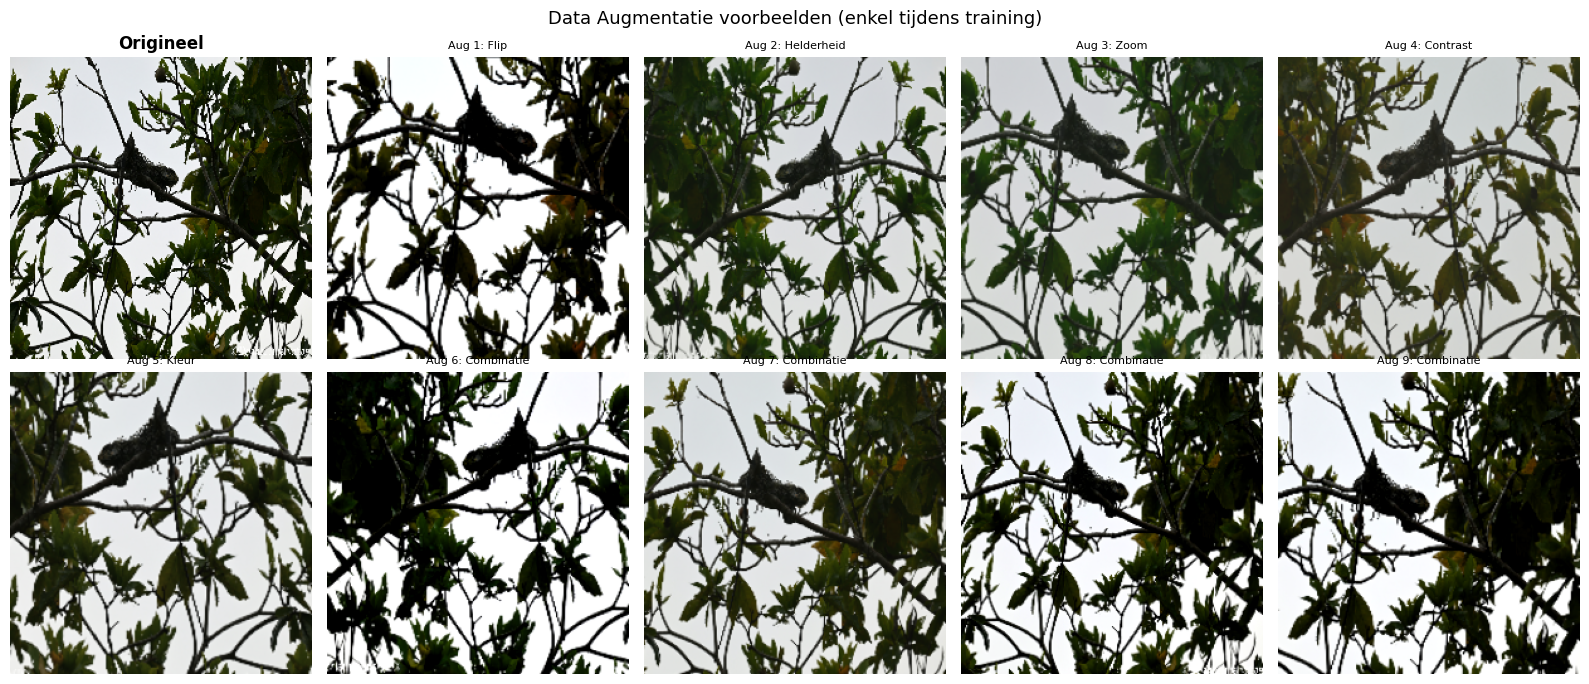

In [11]:
# Augmentatie visualiseren ? controleer of het correct werkt
sample_path  = train_split['filepath'].iloc[0]
sample_label = train_split['label'].iloc[0]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Origineel: raw RGB [0,255] tonen als [0,1]
img_orig, _ = load_image_raw(sample_path, sample_label, augment=False)
img_vis = np.clip(img_orig.numpy() / 255.0, 0, 1)
axes[0][0].imshow(img_vis)
axes[0][0].set_title("Origineel", fontweight='bold')
axes[0][0].axis('off')

# 9 augmentaties
aug_labels = ["Flip", "Helderheid", "Zoom", "Contrast",
              "Kleur", "Combinatie", "Combinatie", "Combinatie", "Combinatie"]
for i in range(9):
    img_aug, _ = load_image_raw(sample_path, sample_label, augment=True)
    img_vis = np.clip(img_aug.numpy() / 255.0, 0, 1)
    r, c = (i + 1) // 5, (i + 1) % 5
    axes[r][c].imshow(img_vis)
    axes[r][c].set_title(f"Aug {i+1}: {aug_labels[i]}", fontsize=8)
    axes[r][c].axis('off')

plt.suptitle("Data Augmentatie voorbeelden (enkel tijdens training)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. 🧠 Eigen CNN bouwen

### Hoe werkt een CNN?

**Convolution:** een klein filter schuift over de afbeelding en detecteert lokale patronen (randen, texturen). Het netwerk leert zelf welke filters nuttig zijn.

**Pooling:** verkleint de feature map zodat het netwerk minder parameters heeft en sneller rekent.

**Global Average Pooling:** in plaats van alles plat te maken (flatten), nemen we het gemiddelde per feature map — dit is efficiënter en vermindert overfitting.

**Structuur van ons CNN:**
```
Input (224×224×3)
  ↓
Conv blok 1: 32 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Conv blok 2: 64 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Conv blok 3: 128 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Conv blok 4: 256 filters (3×3) → BatchNorm → MaxPool → Dropout
  ↓
Global Average Pooling
  ↓
Dense(512) → BatchNorm → Dropout(0.5)
  ↓
Dense(7, softmax)  → voorspelling
```

In [12]:
def build_own_cnn(input_shape, num_classes):
    """Eigen CNN van nul – geen voorgetrainde weights."""
    model = models.Sequential(name='Eigen_CNN')

    # Conv blok 1 – detecteert basistexturen (randen, kleuren)
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv1b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Conv blok 2 – leert complexere vormen
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Conv blok 3 – hogere abstractieniveaus
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='conv3b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Conv blok 4 – fijne details en soortskenmerken
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4a'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='conv4b'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # Classificatie hoofd
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

cnn_model = build_own_cnn((*IMG_SIZE, 3), NUM_CLASSES)
cnn_model.summary()

/home/seppe/miniforge3/envs/dl-gpu/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Eigen_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 240, 240, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 240, 240, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 240, 240, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 120, 120, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 120, 120, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 120, 120, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 60, 60, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4a (Conv2D)                 │ (None, 30, 30, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 30, 30, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4b (Conv2D)                 │ (None, 30, 30, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,311,399 (5.00 MB)

 Trainable params: 1,309,415 (5.00 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [13]:
# Eigen CNN compileren met Cosine Decay learning rate schedule (bonus)
steps_per_epoch = len(train_split) // BATCH_SIZE
lr_schedule_cnn = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * 30
)

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_cnn),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_cnn.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print("=== Eigen CNN trainen ===")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks_cnn
)

=== Eigen CNN trainen ===
Epoch 1/30


I0000 00:00:1778059135.737015   13207 service.cc:153] XLA service 0x7b7ed0048db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778059135.737106   13207 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778059136.012820   13207 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778059137.108297   13207 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778059137.365912   13207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6727__.91
I0000 00:00:1778059176.805372   13207 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1666 - loss: 2.7011

I0000 00:00:1778059183.748448   13208 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6727__.91


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.1668 - loss: 2.6980
Epoch 1: val_accuracy improved from None to 0.14607, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 76s 455ms/step - accuracy: 0.1771 - loss: 2.4966 - val_accuracy: 0.1461 - val_loss: 408.5082
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1605 - loss: 2.3739
Epoch 2: val_accuracy did not improve from 0.14607
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.1828 - loss: 2.3459 - val_accuracy: 0.1311 - val_loss: 445.2748
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1934 - loss: 2.2539
Epoch 3: val_accuracy did not improve from 0.14607
67/67 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - accuracy: 0.2165 - loss: 2.2008 - val_accuracy: 0.1423 - val_loss: 89.4341
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2341 - loss: 2.1596
Epoch 4: val_accuracy did not improve from 0.14607
67/67 ━━━━━━━━━━━━━━━━━━━━

---
## 5. 📈 Training visualiseren – Eigen CNN

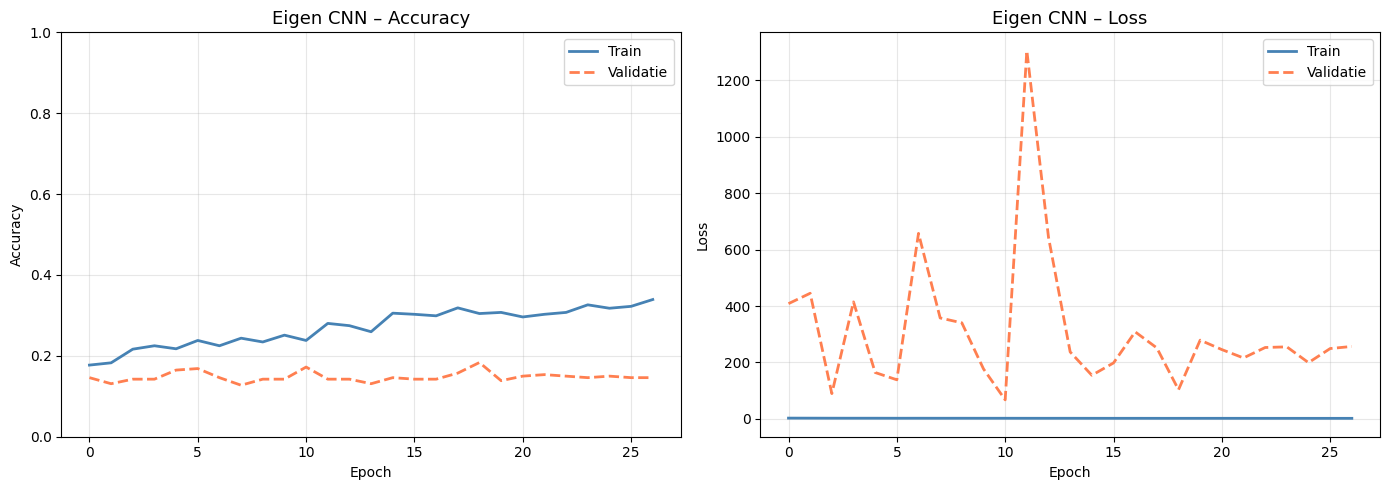

In [14]:
def plot_history(history, title):
    """Loss en accuracy curves voor train en validatie."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train',      color='steelblue', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validatie',  color='coral',     linewidth=2, linestyle='--')
    ax1.set_title(f'{title} – Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1)

    ax2.plot(history.history['loss'],     label='Train',     color='steelblue', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validatie', color='coral',     linewidth=2, linestyle='--')
    ax2.set_title(f'{title} – Loss', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Eigen CNN")

---
## 6. ?? Transfer Learning ? EfficientNetV2M High Accuracy

### Wat zegt de transfer-learning powerpoint?
Een pretrained netwerk bestaat uit een **body** en een **head**. De body heeft op ImageNet al algemene visuele filters geleerd: randen, texturen, vormen en objectonderdelen. Wij vervangen de head door een 7-klassen classifier voor hagedissen.

### Verbetering voor hogere Kaggle score
De extra tips zeggen: probeer `EfficientNetV2M` of `EfficientNetV2L`, verhoog `NUM_TTA` naar 10, voeg `MixUp`/`CutMix` toe en ensemble eventueel meerdere modellen.

In deze notebook gebruiken we standaard **EfficientNetV2M** omdat dit sterk is en nog haalbaar is op een RTX 4050. Als je genoeg VRAM hebt, kan je bovenaan `BACKBONE_NAME = "EfficientNetV2L"` zetten.

**Strategie volgens de slides:**
- **Fase 1:** backbone bevriezen, alleen classificatie-hoofd trainen.
- **Fase 2:** laatste lagen voorzichtig fine-tunen met lage learning rate.
- **GAP:** Global Average Pooling houdt het aantal parameters lager dan Flatten en vermindert overfitting.

In [15]:
def get_efficientnet_backbone(name):
    backbones = {
        "EfficientNetV2M": keras.applications.EfficientNetV2M,
        "EfficientNetV2L": keras.applications.EfficientNetV2L,
    }
    if name not in backbones:
        raise ValueError(f"Onbekende backbone: {name}. Kies EfficientNetV2M of EfficientNetV2L.")
    return backbones[name]

BackboneClass = get_efficientnet_backbone(BACKBONE_NAME)
base_model = BackboneClass(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,  # raw RGB [0,255] -> correcte EfficientNetV2 preprocessing
)
base_model.trainable = False

print(f"{BACKBONE_NAME} lagen: {len(base_model.layers)}")
print(f"Trainbare parameters backbone bevroren: {sum(np.prod(v.shape) for v in base_model.trainable_variables):,}")

inputs = keras.Input(shape=(*IMG_SIZE, 3), name='image')
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='global_average_pooling')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='species')(x)

tl_model = keras.Model(inputs, outputs, name=f'{BACKBONE_NAME}_HighAccuracy')
tl_model.summary()

214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
EfficientNetV2M lagen: 740
Trainbare parameters backbone bevroren: 0


Model: "EfficientNetV2M_HighAccuracy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 8, 8, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,817,019 (205.30 MB)

 Trainable params: 663,047 (2.53 MB)

 Non-trainable params: 53,153,972 (202.77 MB)

In [ ]:
# Fase 1: hoofd trainen ? backbone bevroren
# MixUp/CutMix produceert soft labels; daarom gebruiken we CategoricalCrossentropy.
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=8e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=['accuracy']
)

callbacks_fase1 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'best_{BACKBONE_NAME.lower()}_fase1.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print(f"=== Fase 1: Classificatie-hoofd trainen ({BACKBONE_NAME}) ===")
history_tl1 = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_fase1
)

plot_history(history_tl1, f"{BACKBONE_NAME} ? Fase 1 (hoofd)")

=== Fase 1: Classificatie-hoofd trainen (EfficientNetV2M) ===
Epoch 1/20


I0000 00:00:1778059510.068199   13208 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68614__.718
E0000 00:00:1778059512.880909   13208 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059515.069455   13208 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059517.297925   13208 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059520.526800   13208 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059524.200680   13208 cuda_timer.cc:87] Delay kernel timed ou

66/67 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.2975 - loss: 2.6510

I0000 00:00:1778059558.995613   13205 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_68614__.718
E0000 00:00:1778059564.021183   13205 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059567.056643   13205 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059568.734622   13205 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059569.972029   13205 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778059571.289423   13205 cuda_timer.cc:87] Delay kernel timed ou

In [ ]:
# Fase 2: Fine-tuning ? laatste lagen ontgrendelen
base_model.trainable = True

# V2M heeft veel lagen. Alleen de laatste blokken trainen is stabieler op een kleine dataset.
FINE_TUNE_LAST_N = 80 if BACKBONE_NAME == "EfficientNetV2M" else 100
for layer in base_model.layers[:-FINE_TUNE_LAST_N]:
    layer.trainable = False

# BatchNorm bevriezen tijdens fine-tuning voorkomt instabiele moving averages bij kleine batches.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable = sum(np.prod(v.shape) for v in tl_model.trainable_variables)
print(f"Fine-tune laatste {FINE_TUNE_LAST_N} lagen")
print(f"Trainbare parameters na fine-tuning: {trainable:,}")

steps = max(1, len(train_split) // BATCH_SIZE)
lr_cosine = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=8e-6,
    decay_steps=steps * 35,
    alpha=0.05
)

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_cosine),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy']
)

callbacks_fase2 = [
    EarlyStopping(monitor='val_accuracy', patience=10,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'best_{BACKBONE_NAME.lower()}_fase2.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]

print(f"=== Fase 2: Fine-tuning ({BACKBONE_NAME}) ===")
history_tl2 = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds,
    epochs=35,
    callbacks=callbacks_fase2
)

plot_history(history_tl2, f"{BACKBONE_NAME} ? Fase 2 (fine-tuning)")

---
## 7. 📊 Evaluatie

We evalueren beide modellen op de **validatieset** met:
- Accuracy & loss vergelijking
- Confusion matrix (welke soorten worden verward?)
- Classification report (precision, recall, F1 per klasse)

In [ ]:
# Beste modellen laden
best_cnn_path = Path('best_cnn.keras')
best_tl_path = Path(f'best_{BACKBONE_NAME.lower()}_fase2.keras')

best_cnn = keras.models.load_model(best_cnn_path) if best_cnn_path.exists() else None
best_tl = keras.models.load_model(best_tl_path)

resnet_loss, resnet_acc = best_tl.evaluate(val_ds, verbose=0)
print(f"{'Model':<30} {'Accuracy':>10} {'Loss':>10}")
print("-" * 52)
if best_cnn is not None:
    # Eigen CNN verwacht [0,1], dus maak een aparte validatieset.
    val_ds_cnn = make_dataset(val_split, augment=False, shuffle=False, for_transfer=False)
    cnn_loss, cnn_acc = best_cnn.evaluate(val_ds_cnn, verbose=0)
    print(f"{'Eigen CNN':<30} {cnn_acc:>10.4f} {cnn_loss:>10.4f}")
else:
    cnn_acc = None
    print("Eigen CNN overgeslagen: best_cnn.keras niet gevonden")
print(f"{BACKBONE_NAME + ' (fine-tune)':<30} {resnet_acc:>10.4f} {resnet_loss:>10.4f}")

In [ ]:
# Vergelijking staafdiagram
if cnn_acc is not None:
    models_names = ['Eigen CNN', BACKBONE_NAME]
    accs = [cnn_acc, resnet_acc]
    colors = ['steelblue', 'coral']
else:
    models_names = [BACKBONE_NAME]
    accs = [resnet_acc]
    colors = ['coral']

plt.figure(figsize=(7, 5))
bars = plt.bar(models_names, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=13, fontweight='bold')
plt.title("Validatie Accuracy ? Model vergelijking", fontsize=13)
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix voor het beste model
# Let op: val_ds is niet geshuffled, dus y_true komt overeen met y_pred.
y_pred_proba = best_tl.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_split['label'].tolist()

print(f"=== Classification Report ? {BACKBONE_NAME} ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Absolute aantallen
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (absoluut)", fontsize=13)
axes[0].set_xlabel("Voorspeld")
axes[0].set_ylabel("Werkelijk")
axes[0].tick_params(axis='x', rotation=30)

# Genormaliseerd (recall per rij)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (genormaliseerd)", fontsize=13)
axes[1].set_xlabel("Voorspeld")
axes[1].set_ylabel("Werkelijk")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Verkeerdelijk geclassificeerde afbeeldingen bekijken
val_reset = val_split.reset_index(drop=True)
wrong_idx = np.where(np.array(y_true) != y_pred)[0]
print(f"Fout geclassificeerd door {BACKBONE_NAME}: {len(wrong_idx)}/{len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

show = wrong_idx[:8]
if len(show) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, idx in zip(axes.flatten(), show):
        img = mpimg.imread(val_reset.iloc[idx]['filepath'])
        ax.imshow(img)
        true_name = CLASS_NAMES[y_true[idx]].replace('_', ' ')
        pred_name = CLASS_NAMES[y_pred[idx]].replace('_', ' ')
        ax.set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=7, color='red')
        ax.axis('off')
    for ax in axes.flatten()[len(show):]:
        ax.axis('off')
    plt.suptitle(f"Verkeerdelijk geclassificeerde afbeeldingen ({BACKBONE_NAME})", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Geen fouten op de validatieset.")

---
## 8. ?? Kaggle Submission

We gebruiken **Test Time Augmentation (TTA)** met `NUM_TTA = 10`, zoals in de extra tips. Het model voorspelt elke testafbeelding meerdere keren met kleine variaties en middelt de probabilities.

Er staat ook een optionele ensemble-hook in de code. Als je later meerdere `.keras` modellen traint, kan je die paden toevoegen aan `ENSEMBLE_MODEL_PATHS`; de probabilities worden dan gemiddeld.

In [ ]:
# Test afbeeldingspaden ophalen
test_df = pd.read_csv(TEST_CSV)

def get_test_path(img_id):
    for ext in ['.jpg', '.jpeg', '.png']:
        p = TEST_DIR / f"{img_id}{ext}"
        if p.exists():
            return str(p)
    return None

test_df['filepath'] = test_df['id'].apply(get_test_path)
found = test_df['filepath'].notna().sum()
print(f"Test afbeeldingen gevonden: {found}/{len(test_df)}")
if found < len(test_df):
    print("⚠️ Niet alle testafbeeldingen gevonden – controleer TEST_DIR")

In [ ]:
def load_test_image(filepath, augment=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    if augment:
        img = augment_image(img)
    return img

def make_test_ds(filepaths, augment=False):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(lambda p: load_test_image(p, augment), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def predict_tta(model, filepaths, num_tta=NUM_TTA):
    all_probs = [model.predict(make_test_ds(filepaths, augment=False), verbose=0)]
    for i in range(num_tta - 1):
        all_probs.append(model.predict(make_test_ds(filepaths, augment=True), verbose=0))
        print(f"  TTA run {i+2}/{num_tta} ?")
    return np.mean(all_probs, axis=0)

test_paths = test_df['filepath'].tolist()

# Optionele ensemble: voeg extra modelpaden toe als je meerdere backbones traint.
ENSEMBLE_MODEL_PATHS = [f'best_{BACKBONE_NAME.lower()}_fase2.keras']
# Voorbeeld later: ENSEMBLE_MODEL_PATHS.append('best_resnet_fase2.keras')

print(f"TTA inferentie ({NUM_TTA} runs per model)...")
ensemble_probs = []
for model_path in ENSEMBLE_MODEL_PATHS:
    print(f"Model: {model_path}")
    model_i = keras.models.load_model(model_path)
    ensemble_probs.append(predict_tta(model_i, test_paths, NUM_TTA))

avg_probs = np.mean(ensemble_probs, axis=0)
predicted_labels = np.argmax(avg_probs, axis=1)
confidence = np.max(avg_probs, axis=1)

print(f"\nGemiddelde confidence: {confidence.mean():.3f}")
print("Verdeling voorspellingen:")
for lbl, cnt in sorted(Counter(predicted_labels.tolist()).items()):
    print(f"  {lbl} ({CLASS_NAMES[lbl]}): {cnt}")

In [ ]:
# Confidence visualiseren
plt.figure(figsize=(8, 4))
plt.hist(confidence, bins=20, color='steelblue', edgecolor='black')
plt.axvline(confidence.mean(), color='red', linestyle='--', label=f'Gemiddelde: {confidence.mean():.2f}')
plt.title("Confidence verdeling (testset)")
plt.xlabel("Confidence")
plt.ylabel("Aantal")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Submission aanmaken + valideren
submission = pd.DataFrame({
    'id': test_df['id'].tolist(),
    'label': predicted_labels.tolist()
})

sample_sub = pd.read_csv(SAMPLE_SUB)
assert list(submission.columns) == list(sample_sub.columns), "Kolommen kloppen niet!"
assert len(submission) == len(sample_sub), f"Rijen: {len(submission)} vs {len(sample_sub)}"
assert submission['label'].between(0, NUM_CLASSES - 1).all(), "Ongeldige labels!"

print("Alle sanity checks geslaagd!")
print(submission.head(10))

submission.to_csv('submission_high_accuracy.csv', index=False)
submission.to_csv('submission.csv', index=False)
print("\nsubmission_high_accuracy.csv en submission.csv opgeslagen ? klaar voor Kaggle upload!")

---
## ? Samenvatting & Conclusie

| Onderdeel | Wat is gedaan |
|-----------|---------------|
| **EDA** | Klassen, aantallen, voorbeeldafbeeldingen, afmetingen geanalyseerd |
| **Augmentatie** | Flip, brightness, contrast, saturation, hue, zoom, plus MixUp/CutMix |
| **Eigen CNN** | Didactisch model vanaf nul, zoals in de CNN-powerpoint |
| **Transfer Learning** | EfficientNetV2M/ImageNet, body/head aanpak uit de transfer-learning powerpoint |
| **Trainingstrategie** | Fase 1 backbone bevriezen, fase 2 laatste lagen voorzichtig fine-tunen |
| **LR Schedule** | CosineDecay voor fine-tuning |
| **Evaluatie** | Accuracy/loss curves, confusion matrix, classification report, fout-analyse |
| **Submission** | TTA met 10 runs, optionele ensemble-hook, correcte id-koppeling |

### Conclusie
De high-accuracy versie volgt de powerpoints maar gebruikt sterkere challenge-technieken: EfficientNetV2M als pretrained body, MixUp/CutMix als extra augmentatie, hogere resolutie en meer TTA. Dit zou normaal een betere Kaggle-score geven dan ResNet50V2, zolang de GPU genoeg geheugen heeft.

### Praktische tips
- Krijg je `ResourceExhaustedError` of OOM? Zet `BATCH_SIZE = 8`.
- Wil je V2L proberen? Zet `BACKBONE_NAME = "EfficientNetV2L"`, maar dit is zwaar voor 6GB VRAM.
- Voor een echt ensemble train je later nog een tweede model en voeg je het `.keras` pad toe aan `ENSEMBLE_MODEL_PATHS`.

### GenAI-vermelding
GenAI werd gebruikt om de notebook te structureren, de powerpoints te vertalen naar een TensorFlow/Keras workflow, en high-score technieken zoals EfficientNetV2, MixUp/CutMix, TTA en optioneel ensembling correct in te bouwen. De resultaten blijven afhankelijk van training, validatie en Kaggle-feedback; controleer dus zelf de curves, confusion matrix en submission.